In [1]:
# =========================================================
# IMPORTS
# =========================================================

import os
import gc
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    densenet201,
    efficientnet_b0
)

torch.backends.cudnn.benchmark = True

In [2]:
# =========================================================
# CONFIGURATION
# =========================================================

NUM_CLASSES = 20
BATCH_SIZE = 64
IMG_SIZE = 384

TEMPERATURE = 1.4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

# =========================================================
# DATA PATHS
# =========================================================

DATA_PATH = "/kaggle/input/competitions/ail-7031"
IMG_DIR = os.path.join(DATA_PATH, "images/images")

TEST_CSV = os.path.join(DATA_PATH, "test.csv")
SAMPLE_SUB = os.path.join(DATA_PATH, "sample_submission.csv")

# =========================================================
# MODEL PATHS
# =========================================================

MODEL_DIR = "/kaggle/input/datasets/codingveenitkumar/densenet201-final"

DENSENET_FOLD0 = f"{MODEL_DIR}/DenseNet201_fold_0.pth"
DENSENET_FOLD1 = f"{MODEL_DIR}/DenseNet201_fold_1.pth"
DENSENET_FOLD2 = f"{MODEL_DIR}/DenseNet201_fold_2.pth"
DENSENET_FOLD3 = f"{MODEL_DIR}/DenseNet201_fold_3.pth"

DENSENET_FULL = f"/kaggle/input/datasets/codingveenitkumar/densenet201-final/DenseNet201_FULL_MODEL.pth"
# EFFICIENTNET_FULL = f"/kaggle/input/datasets/codingveenit/final-train/efficientnet_model/EfficientNetB0_FULL_MODEL.pth"

THRESHOLD_PATH = f"/kaggle/input/datasets/codingveenitkumar/densenet201-final/cv_analysis_outputs (2)/best_thresholds.npy"

print("Paths verified.")

Device: cuda
Paths verified.


In [3]:
# =========================================================
# LOAD METADATA
# =========================================================

test_df = pd.read_csv(TEST_CSV)
sample_sub = pd.read_csv(SAMPLE_SUB)

label_cols = sample_sub.columns[1:]

best_thresholds = np.load(THRESHOLD_PATH)

# =========================================================
# LOAD THRESHOLDS (from CV tuning)
# =========================================================

adaptive_thresholds = best_thresholds.copy()

print("Using tuned thresholds from CV:")
print(adaptive_thresholds)

print("Test samples:", len(test_df))
print("Thresholds loaded:", best_thresholds.shape)

Using tuned thresholds from CV:
[0.15 0.35 0.65 0.4  0.2  0.9  0.55 0.3  0.15 0.2  0.4  0.9  0.85 0.2
 0.55 0.1  0.65 0.9  0.85 0.05]
Test samples: 20279
Thresholds loaded: (20,)


In [4]:
# =========================================================
# TEST DATASET
# =========================================================

class TestDataset(Dataset):

    def __init__(self, df, img_dir, transform=None):

        self.ids = df["id"].values
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):

        return len(self.ids)

    def __getitem__(self, idx):

        img_id = self.ids[idx]

        img_path = os.path.join(self.img_dir, img_id)

        if not os.path.exists(img_path):

            if os.path.exists(img_path + ".jpg"):
                img_path += ".jpg"

            elif os.path.exists(img_path + ".png"):
                img_path += ".png"

        if os.path.exists(img_path):
            img = Image.open(img_path).convert("RGB")

        else:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE))

        if self.transform:
            img = self.transform(img)

        return img, img_id

In [5]:
# =========================================================
# TTA TRANSFORMS
# =========================================================

normalize = transforms.Normalize(
    [0.485, 0.456, 0.406],
    [0.229, 0.224, 0.225]
)

tta_transforms = [

    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        normalize
    ]),

    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        normalize
    ]),

    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        normalize
    ])
]

print("TTA passes:", len(tta_transforms))

TTA passes: 3


In [6]:
# # =========================================================
# # TTA TRANSFORMS
# # =========================================================

# normalize = transforms.Normalize(
#     [0.485, 0.456, 0.406],
#     [0.229, 0.224, 0.225]
# )

# tta_transforms = [

#     # 1. Original
#     transforms.Compose([
#         transforms.Resize((IMG_SIZE, IMG_SIZE)),
#         transforms.ToTensor(),
#         normalize
#     ]),

#     # 2. Horizontal Flip
#     transforms.Compose([
#         transforms.Resize((IMG_SIZE, IMG_SIZE)),
#         transforms.RandomHorizontalFlip(p=1.0),
#         transforms.ToTensor(),
#         normalize
#     ]),

#     # 3. Rotate +10 degrees (deterministic)
#     transforms.Compose([
#         transforms.Resize((IMG_SIZE, IMG_SIZE)),
#         transforms.Lambda(lambda x: x.rotate(10)),
#         transforms.ToTensor(),
#         normalize
#     ]),

#     # 4. Rotate -10 degrees (deterministic)
#     transforms.Compose([
#         transforms.Resize((IMG_SIZE, IMG_SIZE)),
#         transforms.Lambda(lambda x: x.rotate(-10)),
#         transforms.ToTensor(),
#         normalize
#     ])
# ]

# print("TTA passes:", len(tta_transforms))

In [7]:
debug = False

if debug:
    print("DEBUG MODE ENABLED")
    tta_transforms = tta_transforms[:1]   # only 2 TTA passes
else:
    print("FULL INFERENCE MODE")

FULL INFERENCE MODE


In [8]:
# =========================================================
# MODEL BUILDERS
# =========================================================

def build_densenet():

    model = densenet201(weights=None)

    num_ftrs = model.classifier.in_features

    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_ftrs, NUM_CLASSES)
    )

    return model


# def build_efficientnet():

#     model = efficientnet_b0(weights=None)

#     num_ftrs = model.classifier[1].in_features

#     model.classifier = nn.Sequential(
#         nn.Dropout(0.4),
#         nn.Linear(num_ftrs, NUM_CLASSES)
#     )

#     return model

In [9]:
# =========================================================
# LOAD MODELS
# =========================================================

def load_model(model_builder, path):

    model = model_builder()

    state_dict = torch.load(path, map_location=DEVICE)

    model.load_state_dict(state_dict)

    model = model.to(DEVICE)

    if torch.cuda.device_count() > 1:
        print("Using", torch.cuda.device_count(), "GPUs")
        model = nn.DataParallel(model)

    model.eval()

    return model


print("Loading models...")

densenet_fold0 = load_model(build_densenet, DENSENET_FOLD0)
densenet_fold1 = load_model(build_densenet, DENSENET_FOLD1)
densenet_fold2 = load_model(build_densenet, DENSENET_FOLD2)
densenet_fold3 = load_model(build_densenet, DENSENET_FOLD3)

densenet_full = load_model(build_densenet, DENSENET_FULL)

# efficientnet_full = load_model(build_efficientnet, EFFICIENTNET_FULL)

print("All models loaded successfully.")

Loading models...
Using 2 GPUs
Using 2 GPUs
Using 2 GPUs
Using 2 GPUs
Using 2 GPUs
All models loaded successfully.


In [10]:
# =========================================================
# TTA INFERENCE ENGINE (FINAL OPTIMIZED)
# =========================================================

def run_tta_inference(model):

    print("Running inference for model...")

    model.eval()

    num_samples = len(test_df)

    tta_logits = np.zeros((num_samples, NUM_CLASSES), dtype=np.float32)

    ids_collector = []

    for i, tta_tf in enumerate(tta_transforms):

        print(f"TTA Pass {i+1}/{len(tta_transforms)}")

        dataset = TestDataset(test_df, IMG_DIR, tta_tf)

        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=4,
            pin_memory=True,
            persistent_workers=True,
            prefetch_factor=2,
            drop_last=False
        )

        start_idx = 0

        with torch.no_grad():

            for imgs, ids in tqdm(loader):

                imgs = imgs.to(DEVICE, non_blocking=True)

                with torch.amp.autocast("cuda", enabled=(DEVICE.type == "cuda")):
                    outputs = model(imgs)

                logits = outputs.detach().cpu().numpy()

                batch_size_current = logits.shape[0]

                tta_logits[start_idx:start_idx + batch_size_current] += logits

                start_idx += batch_size_current

                if i == 0:
                    ids_collector.extend(ids)

    # average across TTA passes
    tta_logits /= len(tta_transforms)

    return tta_logits, ids_collector

In [11]:
# =========================================================
# RUN INFERENCE FOR ALL MODELS (DEBUG FRIENDLY)
# =========================================================

import time
from datetime import datetime


def log(msg):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {msg}")


overall_start = time.time()

log("Starting inference pipeline")

# -------------------------------------------------
# MODEL LIST
# -------------------------------------------------

if debug:
    
    log("DEBUG MODE ENABLED")
    log("Using only 2 models")

    models_to_run = [
        ("DenseNet Fold 0", densenet_fold0),
        ("DenseNet FULL", densenet_full)
    ]

else:

    log("FULL MODE ENABLED")
    log("Running all models")

    models_to_run = [
        ("DenseNet Fold 0", densenet_fold0),
        ("DenseNet Fold 1", densenet_fold1),
        ("DenseNet Fold 2", densenet_fold2),
        ("DenseNet Fold 3", densenet_fold3),
        ("DenseNet FULL", densenet_full),
        # ("EfficientNet FULL", efficientnet_full)
    ]


# -------------------------------------------------
# RUN MODELS
# -------------------------------------------------

logits_results = {}
ids = None

for name, model in models_to_run:

    log(f"Running {name}")

    start = time.time()

    logits, ids_temp = run_tta_inference(model)

    if ids is None:
        ids = ids_temp

    logits_results[name] = logits

    log(f"{name} finished in {(time.time()-start)/60:.2f} minutes")


# -------------------------------------------------
# TOTAL TIME
# -------------------------------------------------

log(f"Total inference time: {(time.time()-overall_start)/60:.2f} minutes")

log("Inference complete")

[12:38:48] Starting inference pipeline
[12:38:48] FULL MODE ENABLED
[12:38:48] Running all models
[12:38:48] Running DenseNet Fold 0
Running inference for model...
TTA Pass 1/3


  0%|          | 0/317 [00:00<?, ?it/s]

TTA Pass 2/3


  0%|          | 0/317 [00:00<?, ?it/s]

TTA Pass 3/3


...

TTA Pass 2/3


  0%|          | 0/317 [00:00<?, ?it/s]

TTA Pass 3/3


  0%|          | 0/317 [00:00<?, ?it/s]

[16:02:50] DenseNet FULL finished in 40.78 minutes
[16:02:50] Total inference time: 204.02 minutes
[16:02:50] Inference complete


In [12]:
# =========================================================
# PREDICTION FUNCTION
# =========================================================

def generate_predictions(logits, name):

    print(f"\nGenerating predictions for {name}")

    scaled_logits = logits / TEMPERATURE

    probs = torch.softmax(
        torch.from_numpy(scaled_logits),
        dim=1
    ).cpu().numpy()

    probs = np.clip(probs, 1e-6, 1-1e-6)

    predictions = []

    for p in probs:

        # detected = np.where(p > best_thresholds)[0]
        detected = np.where(p > adaptive_thresholds)[0]

        if len(detected) == 0:
            pred = np.argmax(p)
        else:
            pred = detected[np.argmax(p[detected])]

        predictions.append(pred)

    predictions = np.array(predictions)

    submission = pd.DataFrame()
    submission["id"] = ids

    for i, col in enumerate(label_cols):
        submission[col] = (predictions == i).astype(int)

    filename = f"submission_{name}.csv"
    submission.to_csv(filename, index=False)

    print(f"{filename} saved.")

    return predictions

In [13]:
# =========================================================
# SINGLE MODEL SUBMISSIONS
# =========================================================

generate_predictions(logits_results["DenseNet Fold 0"], "fold0")

generate_predictions(logits_results["DenseNet Fold 1"], "fold1")

generate_predictions(logits_results["DenseNet Fold 2"], "fold2")

generate_predictions(logits_results["DenseNet Fold 3"], "fold3")

generate_predictions(logits_results["DenseNet FULL"], "densenet_full")


Generating predictions for fold0
submission_fold0.csv saved.

Generating predictions for fold1
submission_fold1.csv saved.

Generating predictions for fold2
submission_fold2.csv saved.

Generating predictions for fold3
submission_fold3.csv saved.

Generating predictions for densenet_full
submission_densenet_full.csv saved.


array([ 0, 19, 19, ...,  8, 19, 19])

In [14]:
# =========================================================
# ENSEMBLE
# =========================================================

if debug:

    print("DEBUG ENSEMBLE")

    logits_fold0 = logits_results["DenseNet Fold 0"]
    logits_densenet_full = logits_results["DenseNet FULL"]

    final_logits = (
        0.7 * logits_fold0 +
        0.3 * logits_densenet_full
    )

    generate_predictions(final_logits, "final_ensemble")

    print("Ensemble logits shape:", final_logits.shape)
    
else:

    print("FULL ENSEMBLE")

    logits_fold0 = logits_results["DenseNet Fold 0"]
    logits_fold1 = logits_results["DenseNet Fold 1"]
    logits_fold2 = logits_results["DenseNet Fold 2"]
    logits_fold3 = logits_results["DenseNet Fold 3"]
    logits_densenet_full = logits_results["DenseNet FULL"]
    # logits_efficientnet_full = logits_results["EfficientNet FULL"]

    print("Averaging DenseNet fold models...")

    densenet_cv_logits = (
        logits_fold0 +
        logits_fold1 +
        logits_fold2 +
        logits_fold3
    ) / 4.0

    print("DenseNet CV ensemble completed.")

    generate_predictions(densenet_cv_logits, "cv_ensemble")

    print("Performing weighted ensemble...")

    final_logits = (
        0.7 * densenet_cv_logits +
        0.3 * logits_densenet_full 
        # + 0.2 * logits_efficientnet_full
    )

    generate_predictions(final_logits, "final_ensemble")

    print("Ensemble logits shape:", final_logits.shape)

FULL ENSEMBLE
Averaging DenseNet fold models...
DenseNet CV ensemble completed.

Generating predictions for cv_ensemble
submission_cv_ensemble.csv saved.
Performing weighted ensemble...

Generating predictions for final_ensemble
submission_final_ensemble.csv saved.
Ensemble logits shape: (20279, 20)


In [15]:
# =========================================================
# SOFTMAX
# =========================================================

print("Applying softmax...")

scaled_logits = final_logits / TEMPERATURE

final_probs = torch.softmax(
    torch.from_numpy(scaled_logits),
    dim=1
).cpu().numpy()

final_probs = np.clip(final_probs, 1e-6, 1-1e-6)
max_probs = final_probs.max(axis=1)

print("Probability matrix shape:", final_probs.shape)

print("Confidence stats:")
print("Mean:", max_probs.mean())
print("Min:", max_probs.min())
print("Max:", max_probs.max())

Applying softmax...
Probability matrix shape: (20279, 20)
Confidence stats:
Mean: 0.49152708
Min: 0.17007247
Max: 0.803272


In [16]:
# # =========================================================
# # PROBABILITY SHARPENING
# # =========================================================

# print("Applying probability sharpening...")

# SHARPEN_ALPHA = 1.3

# final_probs = np.power(final_probs, SHARPEN_ALPHA)
# final_probs = final_probs / final_probs.sum(axis=1, keepdims=True)

# print("Sharpening complete.")

# max_probs = final_probs.max(axis=1)

# print("Sharpened confidence stats:")
# print("Mean:", max_probs.mean())
# print("Min:", max_probs.min())
# print("Max:", max_probs.max())

In [17]:
# # =========================================================
# # ADAPTIVE THRESHOLD ADJUSTMENT
# # =========================================================

# print("Applying adaptive threshold adjustment...")

# class_means = final_probs.mean(axis=0)

# adaptive_thresholds = best_thresholds * (
#     1 + 0.15 * (class_means - class_means.mean())
# )

# # =========================================================
# # THRESHOLD SMOOTHING
# # =========================================================

# adaptive_thresholds = 0.7 * adaptive_thresholds + 0.3 * best_thresholds

# print("Original thresholds:")
# print(best_thresholds)

# print("Adaptive thresholds:")
# print(adaptive_thresholds)

In [18]:
# # =========================================================
# # LOAD THRESHOLDS (from CV tuning)
# # =========================================================

# adaptive_thresholds = best_thresholds.copy()

# print("Using tuned thresholds from CV:")
# print(adaptive_thresholds)

In [19]:
# =========================================================
# THRESHOLD + MARGIN RULE
# =========================================================

print("Applying thresholds and margin rule...")


predictions = []

MARGIN_THRESHOLD = 0.08

for p in final_probs:

    detected = np.where(p > adaptive_thresholds)[0]

    if len(detected) == 0:
        pred = np.argmax(p)
    else:
        pred = detected[np.argmax(p[detected])]

    top2_idx = np.argsort(p)[-2:]
    margin = p[top2_idx[-1]] - p[top2_idx[-2]]

    if margin < MARGIN_THRESHOLD:
        pred = np.argmax(p)

    predictions.append(pred)

predictions = np.array(predictions)

print("Prediction generation complete.")

Applying thresholds and margin rule...
Prediction generation complete.


Prediction distribution:
Class 00: 219
Class 01: 122
Class 02: 4
Class 03: 12
Class 04: 787
Class 05: 0
Class 06: 2
Class 07: 2
Class 08: 415
Class 09: 182
Class 10: 145
Class 11: 7
Class 12: 0
Class 13: 96
Class 14: 1
Class 15: 0
Class 16: 0
Class 17: 4
Class 18: 0
Class 19: 18281


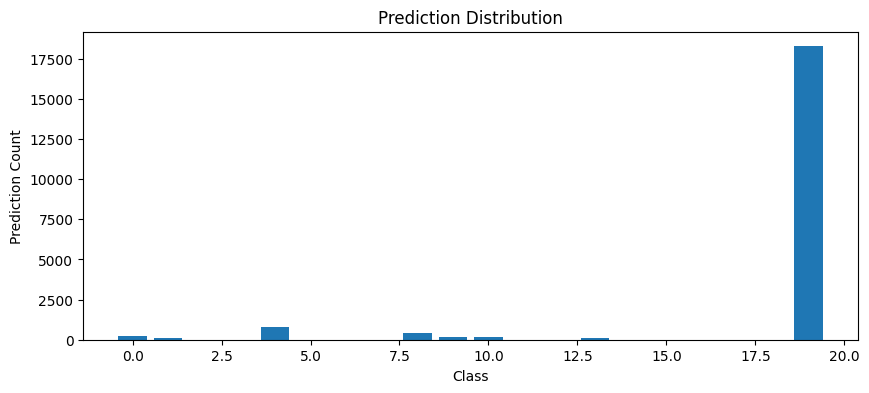

In [20]:
# =========================================================
# PREDICTION DISTRIBUTION CHECK
# =========================================================

print("Prediction distribution:")

pred_counts = pd.Series(predictions).value_counts().sort_index()

for cls in range(NUM_CLASSES):
    
    count = pred_counts.get(cls, 0)
    
    print(f"Class {cls:02d}: {count}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.bar(pred_counts.index, pred_counts.values)
plt.xlabel("Class")
plt.ylabel("Prediction Count")
plt.title("Prediction Distribution")
plt.show()

In [21]:
pseudo_df = pd.DataFrame({
    "id": ids,
    "pred": predictions,
    "confidence": max_probs
})

pseudo_df.to_csv("test_predictions_with_confidence.csv", index=False)

In [22]:
# # =========================================================
# # CREATE SUBMISSION
# # =========================================================

# submission = pd.DataFrame()

# submission["id"] = ids

# for i, col in enumerate(label_cols):

#     submission[col] = (predictions == i).astype(int)

# submission.to_csv("submission.csv", index=False)

# print("submission.csv saved successfully.")
# print(submission.head())

In [23]:
# =========================================================
# CLEANUP
# =========================================================

for var in [
    "logits_fold0",
    "logits_fold1",
    "logits_fold2",
    "logits_fold3",
    "logits_densenet_full",
    "logits_efficientnet_full",
    "final_logits"
]:
    if var in globals():
        del globals()[var]